In [1]:
import warnings
warnings.filterwarnings("ignore")

import time
import pickle
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import AdaBoostClassifier

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [2]:
df = pd.read_csv("processed_dataset.csv")

df.head()

,cat__alert_green,cat__alert_orange,cat__alert_red,cat__alert_yellow,cat__net_ak,cat__net_at,cat__net_ci,cat__net_duputel,cat__net_hv,cat__net_nc,...,num__longitude,num__Year,num__Month,num__Day,num__Hour,num__Energy_Index,num__Tsunami_Flag,num__High_Alert,num__Years_Ago,Damage_Level
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.985112,1.582253,0.40483,0.083822,0.013187,-0.106398,-0.693889,-0.196014,-1.582253,0
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-1.189010,1.582253,0.11792,0.438001,-1.725784,-0.106398,-0.693889,-0.196014,-1.582253,0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-1.037814,1.582253,0.11792,0.201882,-1.291041,-0.105297,-0.693889,-0.196014,-1.582253,0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-1.807072,1.582253,0.11792,0.083822,-0.856298,-0.079118,1.441153,-0.196014,-1.582253,3
4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,-1.807898,1.582253,0.11792,0.083822,-0.856298,-0.066762,1.441153,-0.196014,-1.582253,2


In [3]:
X = df.drop("Damage_Level", axis=1)

y = df["Damage_Level"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

In [5]:
print("Training Shape :",X_train.shape)

print("Testing Shape :",X_test.shape)

Training Shape : (800, 110)
Testing Shape : (200, 110)


In [6]:
models = {

    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Random Forest": RandomForestClassifier(random_state=42),

    "Gradient Boosting": GradientBoostingClassifier(random_state=42),

    "Extra Trees": ExtraTreesClassifier(random_state=42),

    "AdaBoost": AdaBoostClassifier(random_state=42),

    "KNN": KNeighborsClassifier(),

    "Naive Bayes": GaussianNB(),

    "SVM": SVC()

}

In [7]:
cv = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=42

)

In [8]:
results = []

In [9]:
for name, model in models.items():

    start = time.time()

    cv_score = cross_val_score(

        model,

        X_train,

        y_train,

        cv=cv,

        scoring="accuracy"

    )

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    training_time = time.time() - start

    accuracy = accuracy_score(y_test, prediction)

    precision = precision_score(

        y_test,

        prediction,

        average="weighted"

    )

    recall = recall_score(

        y_test,

        prediction,

        average="weighted"

    )

    f1 = f1_score(

        y_test,

        prediction,

        average="weighted"

    )

    results.append({

        "Model":name,

        "CV Mean":cv_score.mean(),

        "CV Std":cv_score.std(),

        "Accuracy":accuracy,

        "Precision":precision,

        "Recall":recall,

        "F1 Score":f1,

        "Training Time (s)":training_time

    })

In [10]:
results = pd.DataFrame(results)

results

,Model,CV Mean,CV Std,Accuracy,Precision,Recall,F1 Score,Training Time (s)
0,Logistic Regression,0.92125,0.022913,0.930,0.931021,0.930,0.929628,1.061083
1,Decision Tree,0.86125,0.030721,0.920,0.920032,0.920,0.919880,0.117867
2,Random Forest,0.84125,0.028940,0.840,0.841051,0.840,0.836270,2.598733
3,Gradient Boosting,0.93125,0.008839,0.950,0.950464,0.950,0.949993,16.948704
4,Extra Trees,0.84125,0.012870,0.845,0.845189,0.845,0.844350,2.302988
5,AdaBoost,0.62250,0.016583,0.785,0.834003,0.785,0.780635,1.681730
6,KNN,0.62875,0.030516,0.675,0.688734,0.675,0.671573,0.398840
7,Naive Bayes,0.37375,0.069530,0.380,0.557696,0.380,0.342500,0.070671
8,SVM,0.86250,0.014252,0.915,0.917917,0.915,0.914195,0.557682


In [11]:
results = results.sort_values(

    by="CV Mean",

    ascending=False

)

results

,Model,CV Mean,CV Std,Accuracy,Precision,Recall,F1 Score,Training Time (s)
3,Gradient Boosting,0.93125,0.008839,0.950,0.950464,0.950,0.949993,16.948704
0,Logistic Regression,0.92125,0.022913,0.930,0.931021,0.930,0.929628,1.061083
8,SVM,0.86250,0.014252,0.915,0.917917,0.915,0.914195,0.557682
1,Decision Tree,0.86125,0.030721,0.920,0.920032,0.920,0.919880,0.117867
2,Random Forest,0.84125,0.028940,0.840,0.841051,0.840,0.836270,2.598733
4,Extra Trees,0.84125,0.012870,0.845,0.845189,0.845,0.844350,2.302988
6,KNN,0.62875,0.030516,0.675,0.688734,0.675,0.671573,0.398840
5,AdaBoost,0.62250,0.016583,0.785,0.834003,0.785,0.780635,1.681730
7,Naive Bayes,0.37375,0.069530,0.380,0.557696,0.380,0.342500,0.070671


In [12]:
best_model_name = results.iloc[0]["Model"]

best_model_name

'Gradient Boosting'

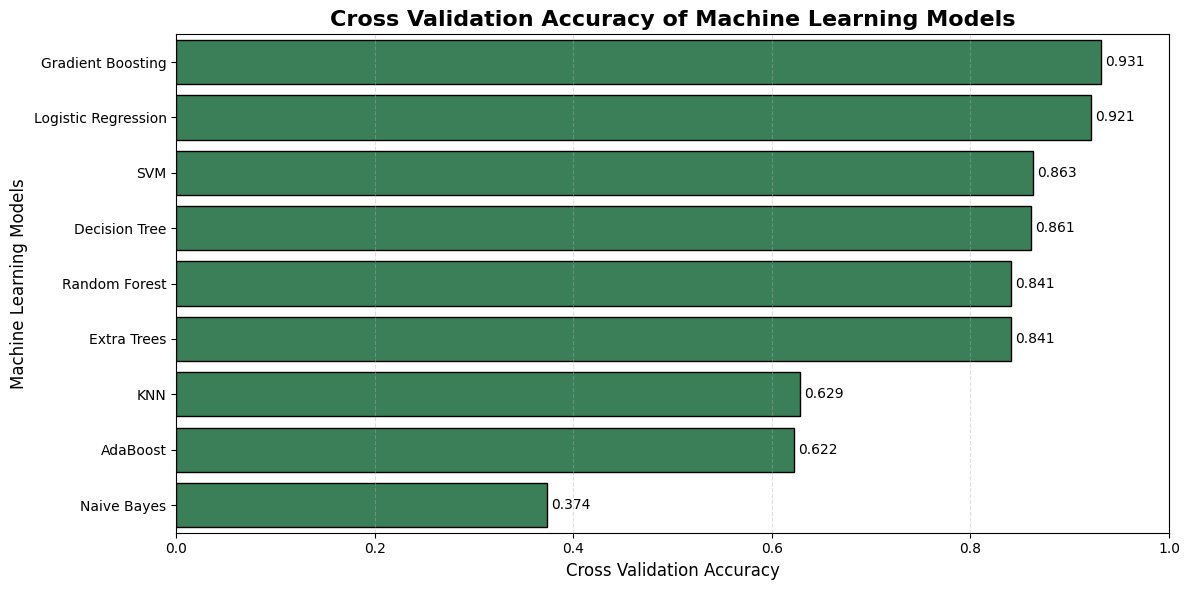

In [14]:
plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=results,
    x="CV Mean",
    y="Model",
    color="#2E8B57",      # Professional Sea Green
    edgecolor="black"
)

# Add value labels
for i in ax.containers:
    ax.bar_label(i, fmt="%.3f", fontsize=10, padding=3)

plt.title(
    "Cross Validation Accuracy of Machine Learning Models",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Cross Validation Accuracy", fontsize=12)
plt.ylabel("Machine Learning Models", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.xlim(0, 1)

plt.tight_layout()
plt.show()

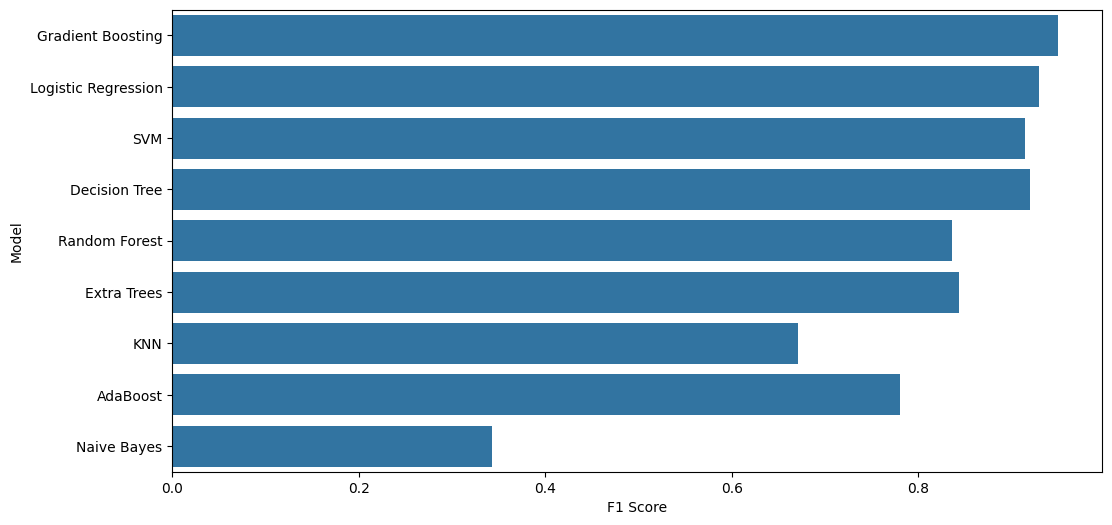

In [15]:
plt.figure(figsize=(12,6))

sns.barplot(

    data=results,

    x="F1 Score",

    y="Model"

)

plt.show()

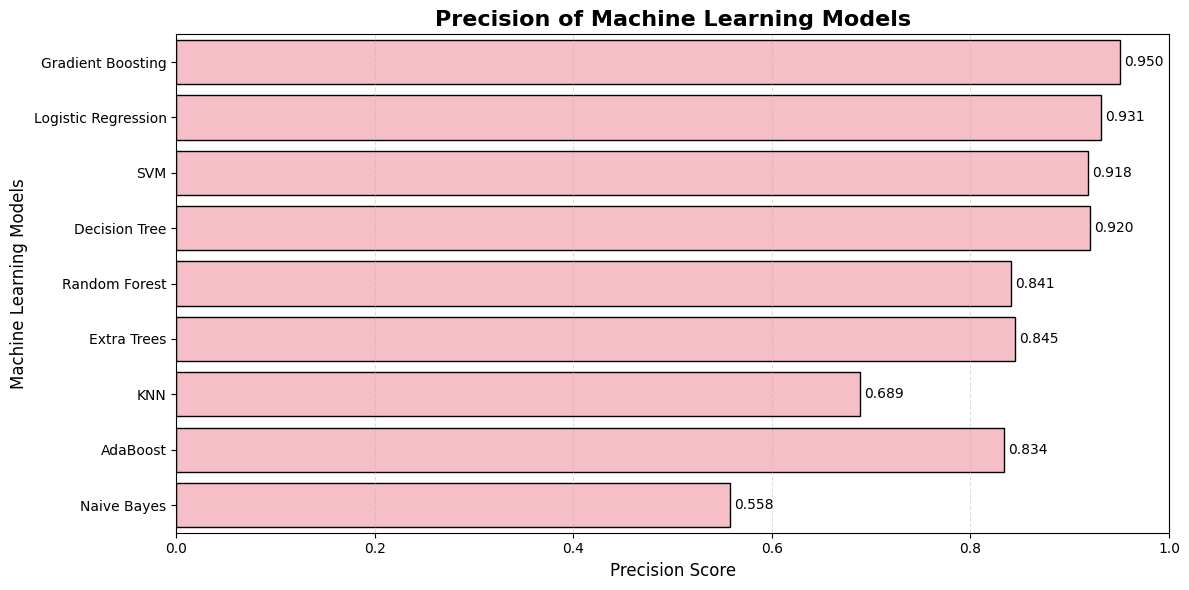

In [18]:
plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=results,
    x="Precision",
    y="Model",
    color="#FFB6C1",      # Light Pink
    edgecolor="black"
)

# Add value labels
for i in ax.containers:
    ax.bar_label(i, fmt="%.3f", fontsize=10, padding=3)

plt.title(
    "Precision of Machine Learning Models",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Precision Score", fontsize=12)
plt.ylabel("Machine Learning Models", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.xlim(0, 1)

plt.tight_layout()
plt.show()

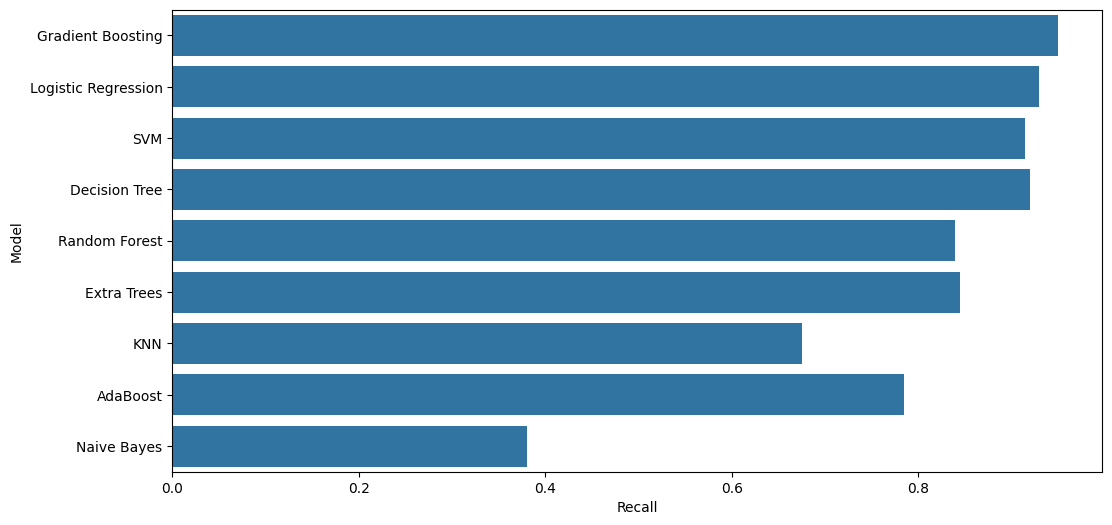

In [17]:
plt.figure(figsize=(12,6))

sns.barplot(

    data=results,

    x="Recall",

    y="Model"

)

plt.show()

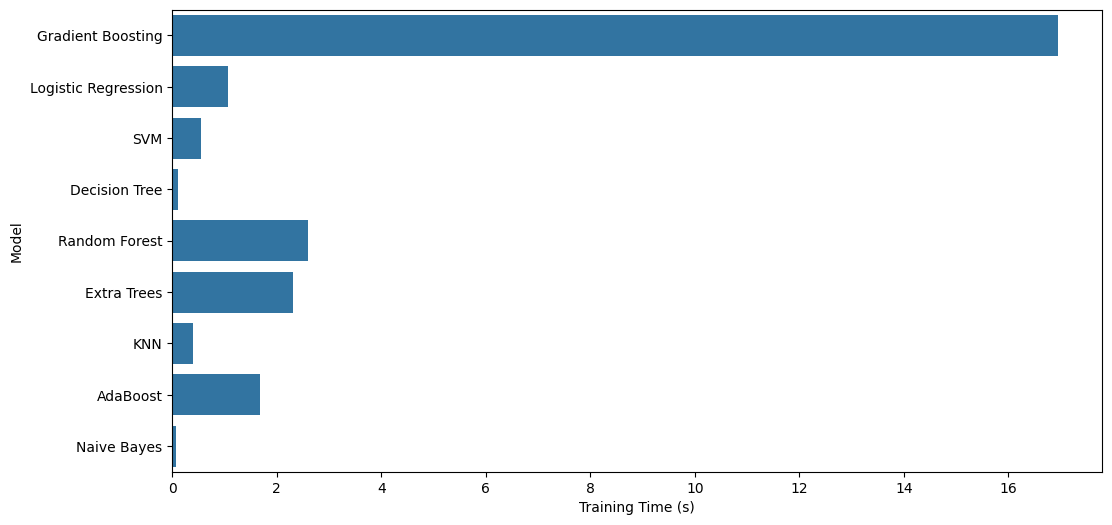

In [19]:
plt.figure(figsize=(12,6))

sns.barplot(

    data=results,

    x="Training Time (s)",

    y="Model"

)

plt.show()

In [20]:
results.corr(numeric_only=True)

,CV Mean,CV Std,Accuracy,Precision,Recall,F1 Score,Training Time (s)
CV Mean,1.000000,-0.782889,0.960880,0.936625,0.960880,0.958584,0.390709
CV Std,-0.782889,1.000000,-0.869707,-0.829412,-0.869707,-0.875997,-0.431608
Accuracy,0.960880,-0.869707,1.000000,0.983061,1.000000,0.999709,0.353261
Precision,0.936625,-0.829412,0.983061,1.000000,0.983061,0.978912,0.387029
Recall,0.960880,-0.869707,1.000000,0.983061,1.000000,0.999709,0.353261
F1 Score,0.958584,-0.875997,0.999709,0.978912,0.999709,1.000000,0.347531
Training Time (s),0.390709,-0.431608,0.353261,0.387029,0.353261,0.347531,1.000000


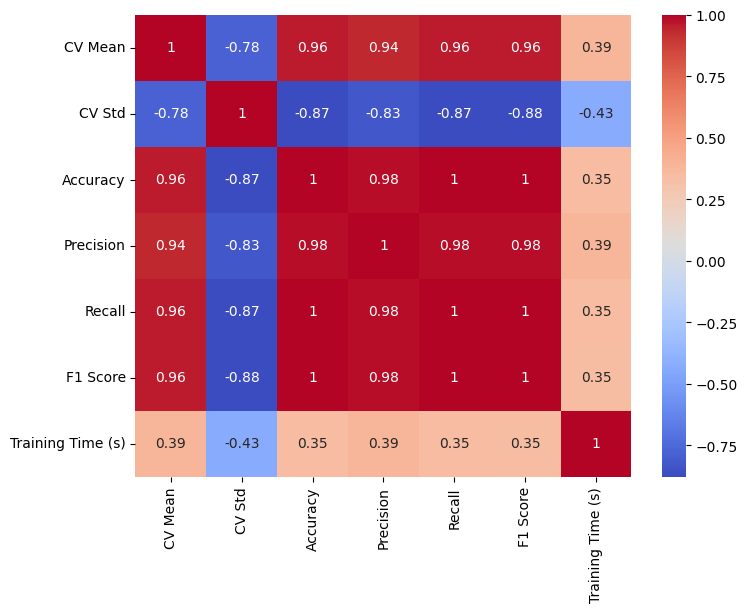

In [21]:
plt.figure(figsize=(8,6))

sns.heatmap(

    results.corr(numeric_only=True),

    annot=True,

    cmap="coolwarm"

)

plt.show()

In [22]:
results.to_csv(

    "cross_validation_results.csv",

    index=False

)

print("Results Saved Successfully")

Results Saved Successfully


In [23]:
print("""

Cross Validation Completed

✔ 9 Machine Learning Models Compared

✔ Stratified 5 Fold CV

✔ Accuracy

✔ Precision

✔ Recall

✔ F1 Score

✔ Training Time

✔ Ranking Generated

Results Ready For Hyperparameter Tuning.

""")



Cross Validation Completed

✔ 9 Machine Learning Models Compared

✔ Stratified 5 Fold CV

✔ Accuracy

✔ Precision

✔ Recall

✔ F1 Score

✔ Training Time

✔ Ranking Generated

Results Ready For Hyperparameter Tuning.




# PART 2

In [60]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

In [63]:
rf_params = {

    "n_estimators":[100,200,300],

    "max_depth":[5,10,20,None],

    "min_samples_split":[2,5,10],

    "min_samples_leaf":[1,2,4],

    "criterion":["gini","entropy"]

}

In [66]:
rf = RandomForestClassifier(random_state=42)

rf_grid = GridSearchCV(

    estimator=rf,

    param_grid=rf_params,

    cv=5,

    scoring="accuracy",

    n_jobs=-1,

    verbose=2

)

rf_grid.fit(X_train,y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [69]:
print("Best Parameters")

print(rf_grid.best_params_)

print()

print("Best Score")

print(rf_grid.best_score_)

Best Parameters
{'criterion': 'entropy', 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Best Score
0.85375


In [80]:
best_rf = rf_grid.best_estimator_

prediction = best_rf.predict(X_test)

In [81]:
print(

classification_report(

y_test,

prediction

)

)

              precision    recall  f1-score   support

           0       0.83      0.88      0.85        50
           1       0.81      0.94      0.87        51
           2       0.82      0.67      0.74        49
           3       0.96      0.92      0.94        50

    accuracy                           0.85       200
   macro avg       0.86      0.85      0.85       200
weighted avg       0.86      0.85      0.85       200



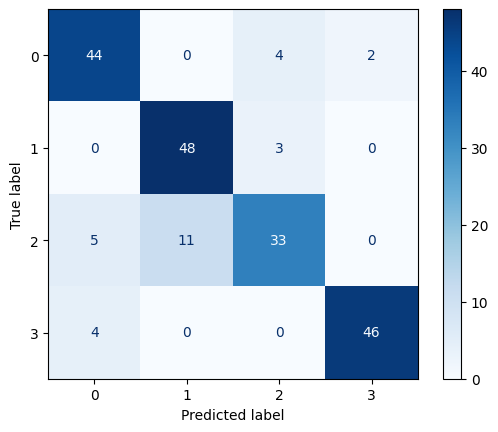

In [82]:
cm = confusion_matrix(

y_test,

prediction

)

disp = ConfusionMatrixDisplay(

confusion_matrix=cm

)

disp.plot(cmap="Blues")

plt.show()

In [83]:
extra_params = {

"n_estimators":[100,200,300,500],

"max_depth":[10,20,30,None],

"min_samples_split":[2,5,10],

"min_samples_leaf":[1,2,4]

}

In [84]:
extra = ExtraTreesClassifier(

random_state=42

)

extra_search = RandomizedSearchCV(

extra,

extra_params,

n_iter=20,

cv=5,

random_state=42,

n_jobs=-1,

verbose=2

)

extra_search.fit(

X_train,

y_train

)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,ExtraTreesCla...ndom_state=42)
,param_distributions,"{'max_depth': [10, 20, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,n_iter,20
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [85]:
print(

extra_search.best_params_

)

print()

print(

extra_search.best_score_

)

{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 30}

0.8375


In [86]:
best_extra = extra_search.best_estimator_

pred_extra = best_extra.predict(X_test)

In [87]:
print(

classification_report(

y_test,

pred_extra

)

)

              precision    recall  f1-score   support

           0       0.79      0.88      0.83        50
           1       0.83      0.88      0.86        51
           2       0.76      0.63      0.69        49
           3       0.96      0.94      0.95        50

    accuracy                           0.83       200
   macro avg       0.83      0.83      0.83       200
weighted avg       0.83      0.83      0.83       200



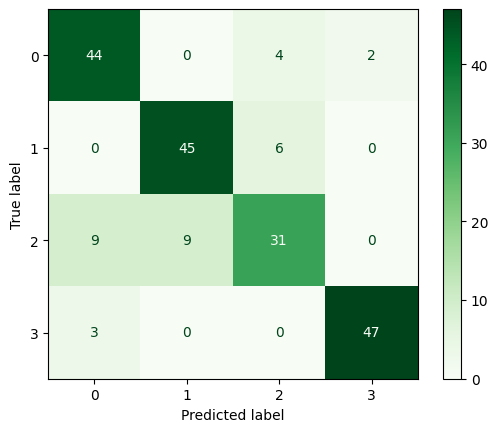

In [88]:
ConfusionMatrixDisplay.from_predictions(

y_test,

pred_extra,

cmap="Greens"

)

plt.show()

In [89]:
svm_params = {

"C":[0.1,1,10],

"kernel":["linear","rbf"],

"gamma":["scale","auto"]

}

In [90]:
svm = SVC()

svm_grid = GridSearchCV(

svm,

svm_params,

cv=5,

n_jobs=-1,

verbose=2

)

svm_grid.fit(

X_train,

y_train

)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


,estimator,SVC()
,param_grid,"{'C': [0.1, 1, ...], 'gamma': ['scale', 'auto'], 'kernel': ['linear', 'rbf']}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,1


In [91]:
print(

svm_grid.best_params_

)

{'C': 1, 'gamma': 'scale', 'kernel': 'linear'}


In [92]:
best_svm = svm_grid.best_estimator_

pred_svm = best_svm.predict(

X_test

)

In [93]:
print(

classification_report(

y_test,

pred_svm

)

)

              precision    recall  f1-score   support

           0       0.91      0.96      0.93        50
           1       0.91      0.98      0.94        51
           2       0.95      0.84      0.89        49
           3       0.98      0.96      0.97        50

    accuracy                           0.94       200
   macro avg       0.94      0.93      0.93       200
weighted avg       0.94      0.94      0.93       200



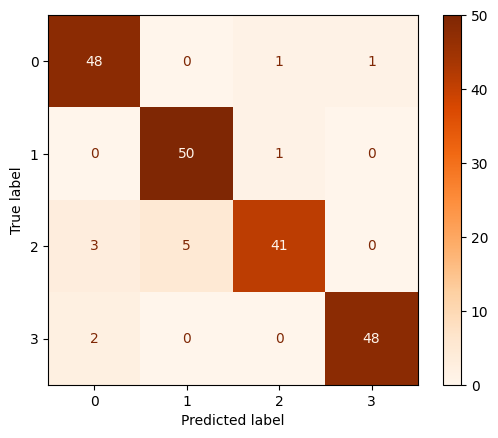

In [94]:
ConfusionMatrixDisplay.from_predictions(

y_test,

pred_svm,

cmap="Oranges"

)

plt.show()

In [95]:
comparison = pd.DataFrame({

"Model":[

"Random Forest",

"Extra Trees",

"SVM"

],

"Accuracy":[

accuracy_score(

y_test,

prediction

),

accuracy_score(

y_test,

pred_extra

),

accuracy_score(

y_test,

pred_svm

)

]

})

comparison

,Model,Accuracy
0,Random Forest,0.855
1,Extra Trees,0.835
2,SVM,0.935


In [96]:
comparison = comparison.sort_values(

"Accuracy",

ascending=False

)

comparison

,Model,Accuracy
2,SVM,0.935
0,Random Forest,0.855
1,Extra Trees,0.835


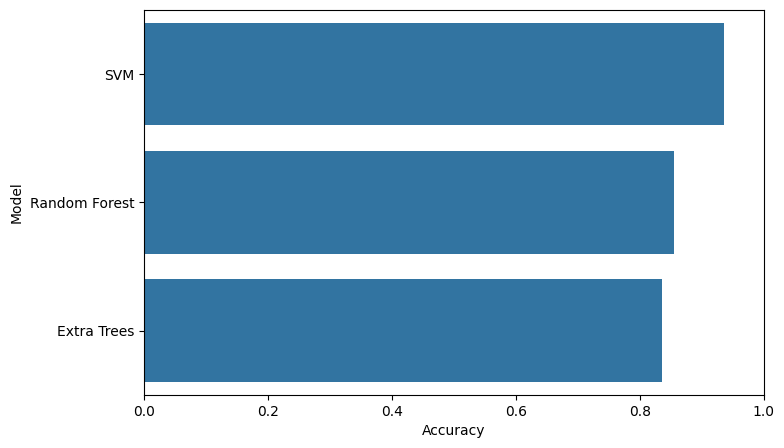

In [97]:
plt.figure(figsize=(8,5))

sns.barplot(

data=comparison,

x="Accuracy",

y="Model"

)

plt.xlim(0,1)

plt.show()

In [98]:
best_name = comparison.iloc[0]["Model"]

print("Best Tuned Model :",best_name)

Best Tuned Model : SVM


In [100]:
if best_name=="Random Forest":

    final_model=best_rf

elif best_name=="Extra Trees":

    final_model=best_extra

else:

    final_model=best_svm

In [101]:
import pickle

pickle.dump(

final_model,

open("tuned_model.pkl","wb")

)

print("Model Saved Successfully")

Model Saved Successfully


In [102]:
comparison.to_csv(

"tuned_model_results.csv",

index=False

)

In [103]:
print("""

Hyperparameter Tuning Completed Successfully

✔ GridSearchCV

✔ RandomizedSearchCV

✔ Random Forest Tuned

✔ Extra Trees Tuned

✔ SVM Tuned

✔ Confusion Matrices

✔ Classification Reports

✔ Best Model Saved

✔ Results Saved

""")



Hyperparameter Tuning Completed Successfully

✔ GridSearchCV

✔ RandomizedSearchCV

✔ Random Forest Tuned

✔ Extra Trees Tuned

✔ SVM Tuned

✔ Confusion Matrices

✔ Classification Reports

✔ Best Model Saved

✔ Results Saved




# part 3

In [104]:
from sklearn.model_selection import learning_curve
from sklearn.model_selection import validation_curve

from sklearn.inspection import permutation_importance

import joblib

In [106]:
train_sizes, train_scores, test_scores = learning_curve(

    estimator=final_model,

    X=X_train,

    y=y_train,

    cv=5,

    scoring="accuracy",

    train_sizes=np.linspace(0.1,1.0,10),

    n_jobs=-1

)

train_mean=train_scores.mean(axis=1)

test_mean=test_scores.mean(axis=1)

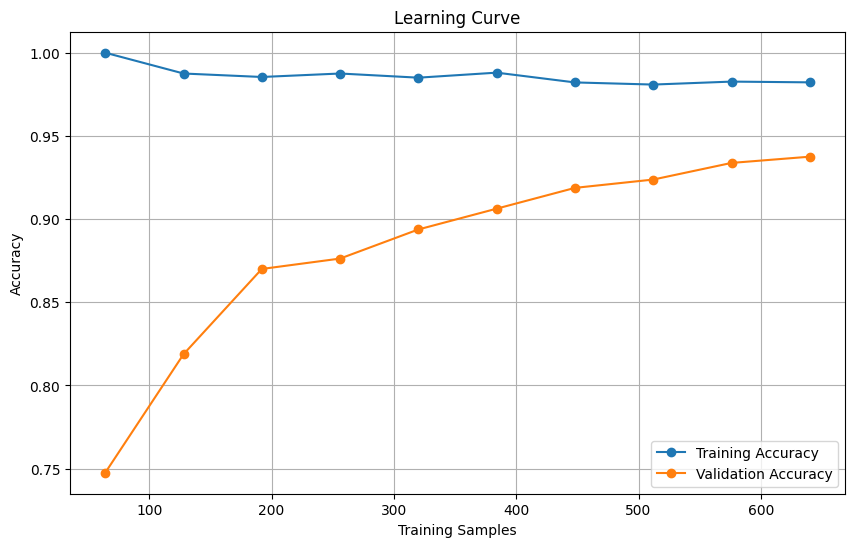

In [107]:
plt.figure(figsize=(10,6))

plt.plot(

train_sizes,

train_mean,

marker="o",

label="Training Accuracy"

)

plt.plot(

train_sizes,

test_mean,

marker="o",

label="Validation Accuracy"

)

plt.xlabel("Training Samples")

plt.ylabel("Accuracy")

plt.title("Learning Curve")

plt.legend()

plt.grid()

plt.show()

In [108]:
param_range=[50,100,150,200,300]

train_scores,test_scores=validation_curve(

RandomForestClassifier(random_state=42),

X_train,

y_train,

param_name="n_estimators",

param_range=param_range,

cv=5,

scoring="accuracy",

n_jobs=-1

)

train_mean=train_scores.mean(axis=1)

test_mean=test_scores.mean(axis=1)

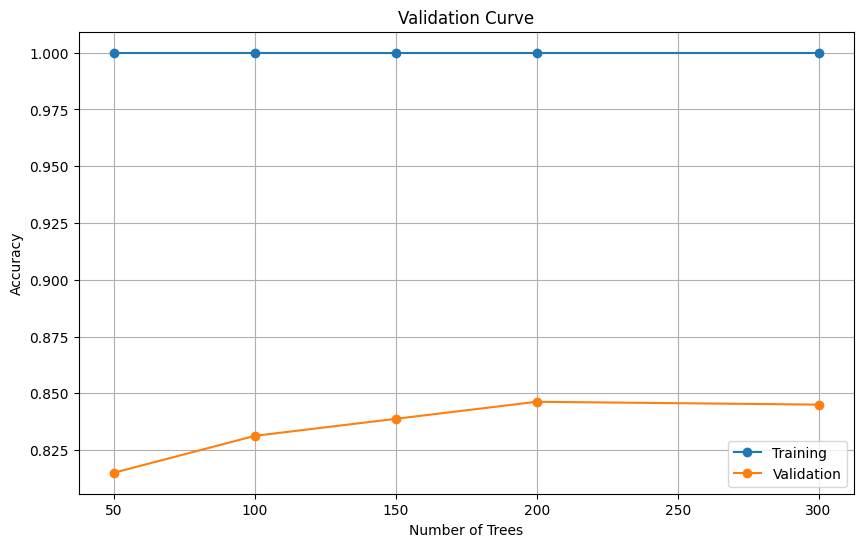

In [109]:
plt.figure(figsize=(10,6))

plt.plot(

param_range,

train_mean,

marker="o",

label="Training"

)

plt.plot(

param_range,

test_mean,

marker="o",

label="Validation"

)

plt.xlabel("Number of Trees")

plt.ylabel("Accuracy")

plt.title("Validation Curve")

plt.legend()

plt.grid()

plt.show()

In [122]:
if hasattr(final_model,"feature_importances_"):

    importance=final_model.feature_importances_

    feature_importance=pd.DataFrame({

        "Feature":X.columns,

        "Importance":importance

    })

    feature_importance=feature_importance.sort_values(

        by="Importance",

        ascending=False

    )

feature_importance.head(20)

,Feature,Importance
92,num__cdi,1.743237
93,num__mmi,0.712787
91,num__magnitude,0.703176
95,num__sig,0.594328
21,cat__magType_mwb,0.142356
102,num__Year,0.103624
109,num__Years_Ago,0.103624
23,cat__magType_mww,0.101751
98,num__gap,0.091441
32,cat__country_Antarctica,0.077328


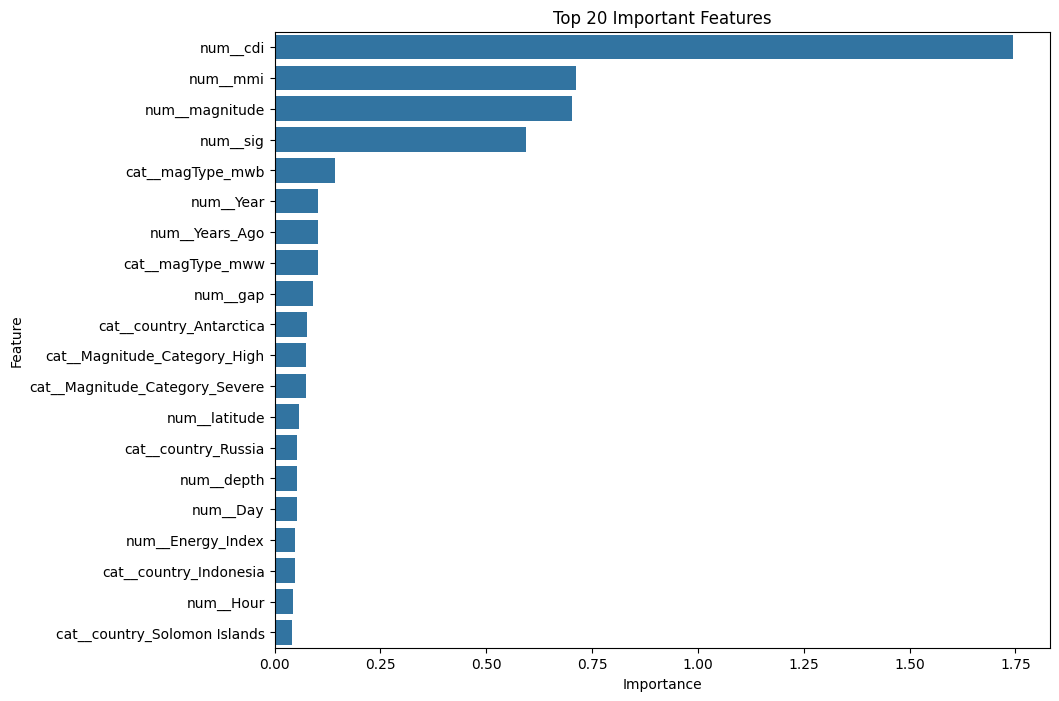

In [123]:
plt.figure(figsize=(10,8))

sns.barplot(

data=feature_importance.head(20),

x="Importance",

y="Feature"

)

plt.title("Top 20 Important Features")

plt.show()

In [124]:
result=permutation_importance(

final_model,

X_test,

y_test,

n_repeats=10,

random_state=42,

n_jobs=-1

)

perm=pd.DataFrame({

"Feature":X.columns,

"Importance":result.importances_mean

})

perm.sort_values(

"Importance",

ascending=False

).head(20)

,Feature,Importance
92,num__cdi,5.225000e-01
91,num__magnitude,2.270000e-01
93,num__mmi,2.040000e-01
95,num__sig,9.500000e-02
101,num__longitude,7.000000e-03
50,cat__country_Indonesia,5.000000e-03
99,num__depth,5.000000e-03
53,cat__country_Japan,4.500000e-03
88,cat__Depth_Category_Deep,4.500000e-03
39,cat__country_Chile,3.500000e-03


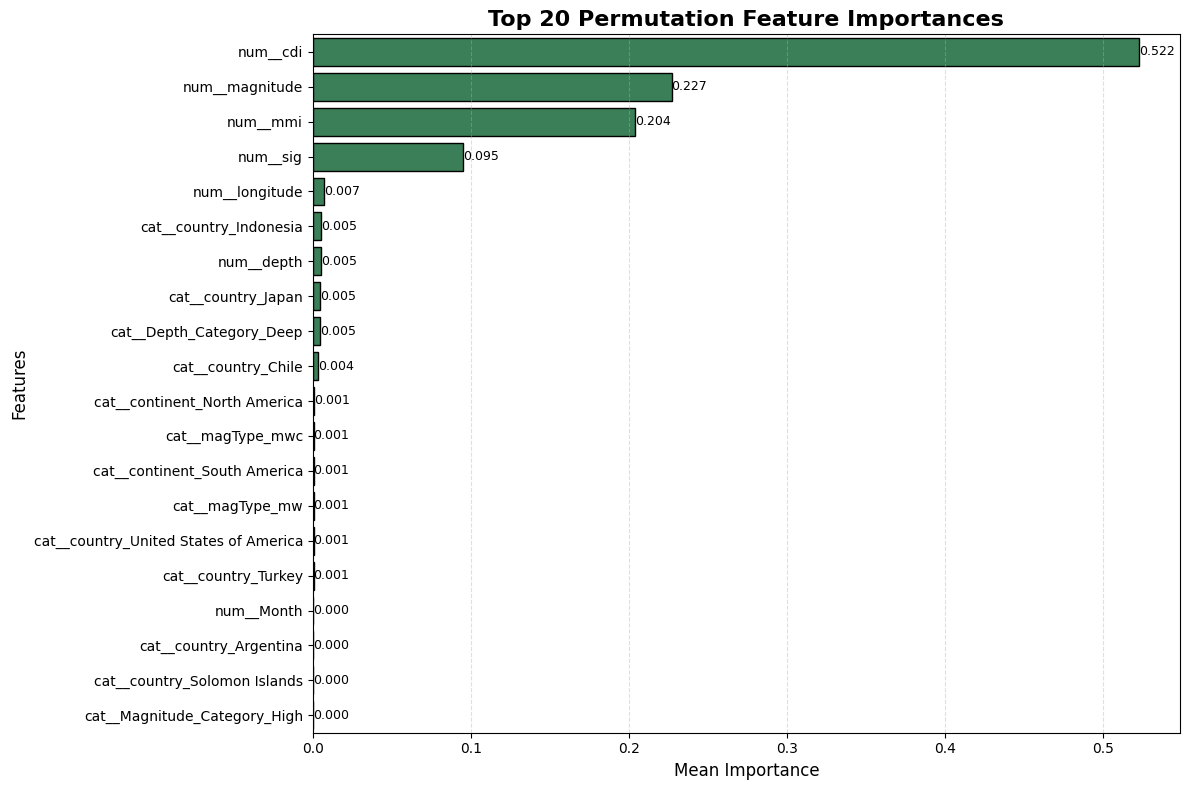

In [137]:
plt.figure(figsize=(12,8))

ax = sns.barplot(
    data=perm.sort_values("Importance", ascending=False).head(20),
    x="Importance",
    y="Feature",
    color="#2E8B57",
    edgecolor="black"
)

for i in ax.containers:
    ax.bar_label(i, fmt="%.3f", fontsize=9)

plt.title(
    "Top 20 Permutation Feature Importances",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Mean Importance", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [138]:
sample=X.iloc[[0]]

prediction=final_model.predict(sample)

prediction

array([0])

In [139]:
label_encoder=pickle.load(

open("label_encoder.pkl","rb")

)

print(

label_encoder.inverse_transform(prediction)

)

['High']


In [140]:
joblib.dump(

final_model,

"final_earthquake_model.pkl"

)

print("Final Model Saved")

Final Model Saved


In [141]:
feature_importance.to_csv(

"feature_importance.csv",

index=False

)

In [142]:
perm.to_csv(

"permutation_importance.csv",

index=False

)

In [143]:
final_prediction=final_model.predict(X_test)

accuracy=accuracy_score(

y_test,

final_prediction

)

precision=precision_score(

y_test,

final_prediction,

average="weighted"

)

recall=recall_score(

y_test,

final_prediction,

average="weighted"

)

f1=f1_score(

y_test,

final_prediction,

average="weighted"

)

print("Accuracy :",round(accuracy,4))

print("Precision :",round(precision,4))

print("Recall :",round(recall,4))

print("F1 Score :",round(f1,4))

Accuracy : 0.935
Precision : 0.9367
Recall : 0.935
F1 Score : 0.9344


In [144]:
summary=pd.DataFrame({

"Metric":[

"Accuracy",

"Precision",

"Recall",

"F1 Score"

],

"Value":[

accuracy,

precision,

recall,

f1

]

})

summary

,Metric,Value
0,Accuracy,0.935000
1,Precision,0.936736
2,Recall,0.935000
3,F1 Score,0.934370


In [145]:
summary.to_csv(

"final_metrics.csv",

index=False

)

In [146]:
print("""

=========================================

EARTHQUAKE DAMAGE PREDICTION

Machine Learning Pipeline Completed

=========================================

✓ Data Cleaning

✓ Exploratory Data Analysis

✓ Feature Engineering

✓ Encoding

✓ Scaling

✓ Model Comparison

✓ Cross Validation

✓ Hyperparameter Tuning

✓ Learning Curve

✓ Validation Curve

✓ Feature Importance

✓ Permutation Importance

✓ Final Model Saved

✓ Ready for Deployment

=========================================

""")




EARTHQUAKE DAMAGE PREDICTION

Machine Learning Pipeline Completed


✓ Data Cleaning

✓ Exploratory Data Analysis

✓ Feature Engineering

✓ Encoding

✓ Scaling

✓ Model Comparison

✓ Cross Validation

✓ Hyperparameter Tuning

✓ Learning Curve

✓ Validation Curve

✓ Feature Importance

✓ Permutation Importance

✓ Final Model Saved

✓ Ready for Deployment



